In [28]:
import json
from io import StringIO
from pathlib import Path
import pandas as pd


def load_highest_result_log(path="../../data/round_3/results_logs/394896.log"):
    path = Path(path)

    with path.open("r", encoding="utf-8") as f:
        raw = json.load(f)

    print(raw.keys())  # helps confirm field names

    # IMC logs often store the activity table under "activitiesLog"
    # but sometimes the structure can differ, so we check safely.
    activities_text = raw.get("activitiesLog")

    if activities_text is None:
        raise KeyError(f"No 'activitiesLog' key found. Available keys: {list(raw.keys())}")

    activities = pd.read_csv(
        StringIO(activities_text),
        sep=";",
        na_values=["", "null", "None"],
    )

    trades = pd.DataFrame(raw.get("tradeHistory", []))
    sandbox = pd.DataFrame(raw.get("sandboxLogs", []))

    return {
        "submission_id": raw.get("submissionId"),
        "activities": activities,
        "trades": trades,
        "sandbox": sandbox,
        "raw": raw,
    }


parsed = load_highest_result_log()
activities_df = parsed["activities"]
trades_df = parsed["trades"]
sandbox_df = parsed["sandbox"]

dict_keys(['submissionId', 'activitiesLog', 'logs', 'tradeHistory'])


In [29]:
DELTA_ONE_PRODUCTS = [
    "HYDROGEL_PACK",
    "VELVETFRUIT_EXTRACT",
]

VOUCHERS = [
    "VEV_4000",
    "VEV_4500",
    "VEV_5000",
    "VEV_5100",
    "VEV_5200",
    "VEV_5300",
    "VEV_5400",
    "VEV_5500",
    "VEV_6000",
    "VEV_6500",
]

ALL_PRODUCTS = DELTA_ONE_PRODUCTS + VOUCHERS

if "global_time" not in activities_df.columns:
    activities_df["global_time"] = activities_df["day"] * 1_000_000 + activities_df["timestamp"]

trades_df["day"] = 2

if "global_time" not in trades_df.columns:
    trades_df["global_time"] = trades_df["day"] * 1_000_000 + trades_df["timestamp"]

activities_df = activities_df.sort_values(["product", "global_time"]).reset_index(drop=True)
trades_df = trades_df.sort_values(["symbol", "global_time"]).reset_index(drop=True)

prices_by_product = {
    product: (
        activities_df[activities_df["product"] == product]
        .sort_values("global_time")
        .reset_index(drop=True)
        .copy()
    )
    for product in ALL_PRODUCTS
}

trades_by_product = {
    product: (
        trades_df[trades_df["symbol"] == product]
        .sort_values("global_time")
        .reset_index(drop=True)
        .copy()
    )
    for product in ALL_PRODUCTS
}

hydro_prices = prices_by_product["HYDROGEL_PACK"]
fruit_prices = prices_by_product["VELVETFRUIT_EXTRACT"]

hydro_trades = trades_by_product["HYDROGEL_PACK"]
fruit_trades = trades_by_product["VELVETFRUIT_EXTRACT"]

vev_4000_prices = prices_by_product["VEV_4000"]
vev_4500_prices = prices_by_product["VEV_4500"]
vev_5000_prices = prices_by_product["VEV_5000"]
vev_5100_prices = prices_by_product["VEV_5100"]
vev_5200_prices = prices_by_product["VEV_5200"]
vev_5300_prices = prices_by_product["VEV_5300"]
vev_5400_prices = prices_by_product["VEV_5400"]
vev_5500_prices = prices_by_product["VEV_5500"]
vev_6000_prices = prices_by_product["VEV_6000"]
vev_6500_prices = prices_by_product["VEV_6500"]

vev_4000_orders = trades_by_product["VEV_4000"]
vev_4500_orders = trades_by_product["VEV_4500"]
vev_5000_orders = trades_by_product["VEV_5000"]
vev_5100_orders = trades_by_product["VEV_5100"]
vev_5200_orders = trades_by_product["VEV_5200"]
vev_5300_orders = trades_by_product["VEV_5300"]
vev_5400_orders = trades_by_product["VEV_5400"]
vev_5500_orders = trades_by_product["VEV_5500"]
vev_6000_orders = trades_by_product["VEV_6000"]
vev_6500_orders = trades_by_product["VEV_6500"]

voucher_prices = (
    activities_df[activities_df["product"].isin(VOUCHERS)]
    .sort_values(["product", "global_time"])
    .reset_index(drop=True)
    .copy()
)

voucher_trades = (
    trades_df[trades_df["symbol"].isin(VOUCHERS)]
    .sort_values(["symbol", "global_time"])
    .reset_index(drop=True)
    .copy()
)

voucher_prices["strike"] = voucher_prices["product"].str.replace("VEV_", "").astype(int)
voucher_trades["strike"] = voucher_trades["symbol"].str.replace("VEV_", "").astype(int)

plot_data_by_product = {
    product: {
        "prices": prices_by_product[product],
        "trades": trades_by_product[product],
    }
    for product in ALL_PRODUCTS
}

In [30]:
fruit_buys = fruit_trades[fruit_trades["buyer"] == "SUBMISSION"]
fruit_sells = fruit_trades[fruit_trades["seller"] == "SUBMISSION"]

hydro_buys = hydro_trades[hydro_trades["buyer"] == "SUBMISSION"]
hydro_sells = hydro_trades[hydro_trades["seller"] == "SUBMISSION"]

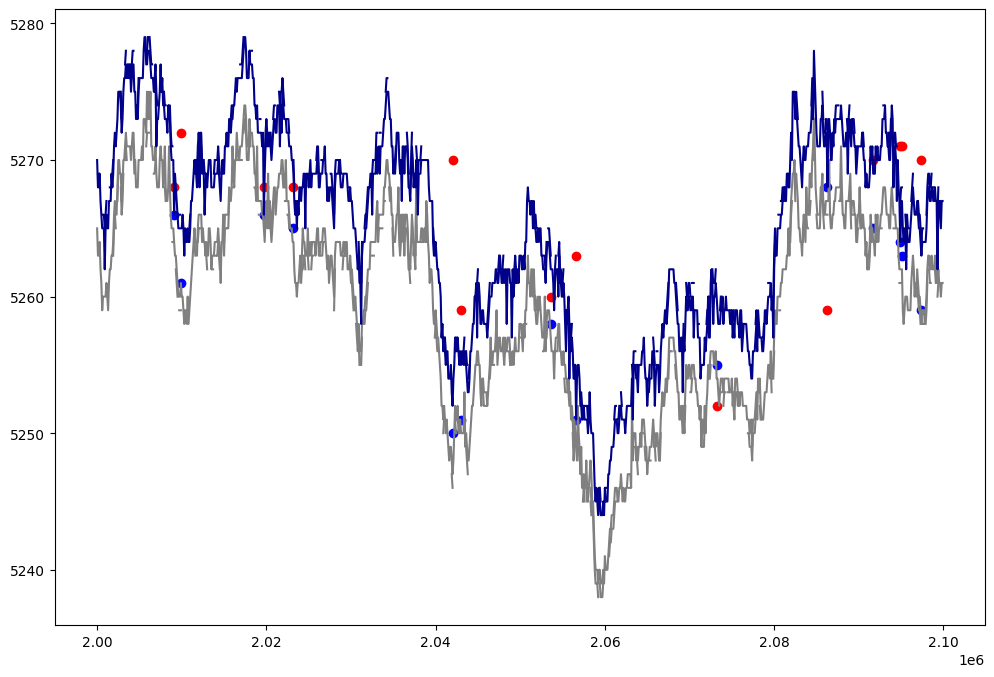

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(fruit_prices["global_time"], fruit_prices["bid_price_1"], color="gray")
plt.plot(fruit_prices["global_time"], fruit_prices["bid_price_2"], color="gray")
plt.plot(fruit_prices["global_time"], fruit_prices["bid_price_3"], color="gray")
plt.plot(fruit_prices["global_time"], fruit_prices["ask_price_1"], color="darkblue")
plt.plot(fruit_prices["global_time"], fruit_prices["ask_price_2"], color="darkblue")
plt.plot(fruit_prices["global_time"], fruit_prices["ask_price_3"], color="darkblue")
plt.scatter(fruit_buys["global_time"], fruit_buys["price"], color="blue")
plt.scatter(fruit_buys["global_time"], fruit_sells["price"], color="red")